<a href="https://colab.research.google.com/github/AlenaResiko/UML/blob/main/notebooks/eval/UML_Plots.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np

results_df = pd.read_csv("/content/drive/MyDrive/weights-UML-train/baseline-results.csv")
results_df.head()

,model,proj_size,dataset,pooler_epochs,encoder_epochs,sts_cos,align_loss_papers_test,uniform_loss_papers_test,align_loss_songs_test,uniform_loss_songs_test,samedoc_papers_test_meancos,samedoc_papers_test_median,samedoc_papers_test_std,samedoc_papers_test_min,samedoc_papers_test_max,samedoc_songs_test_meancos,samedoc_songs_test_median,samedoc_songs_test_std,samedoc_songs_test_min,samedoc_songs_test_max
0,baseline,4,papers,3,3,0.2011,1.308213,-2.4050,0.219642,-0.4638,0.3453,0.4337,0.4593,-0.9927,1,0.8978,0.9318,0.1118,-0.5561,1
1,baseline,16,papers,3,3,0.4599,1.682311,-3.4207,1.134255,-2.2460,0.1491,0.1511,0.2911,-0.7505,1,0.4431,0.4513,0.2414,-0.5277,1
2,baseline,64,papers,3,3,0.6202,1.572155,-3.3691,1.286012,-2.6986,0.1941,0.1901,0.2029,-0.4153,1,0.3612,0.3460,0.1978,-0.2556,1
3,baseline,256,papers,3,3,0.6668,1.697696,-3.6915,1.322055,-2.7982,0.1516,0.1438,0.1831,-0.4162,1,0.3504,0.3264,0.1837,-0.1893,1
4,baseline,767,papers,3,3,0.6684,1.699127,-3.7237,1.377029,-2.9769,0.1412,0.1266,0.1719,-0.2965,1,0.3168,0.2887,0.1822,-0.1568,1


In [ ]:
# 1) x: proj_size, y: sts_cos, red for those that have dataset=papers, blue for dataset=songs
# 2) x: proj_size, y1: align_loss_papers_test, red for those that have dataset=papers, blue for dataset=songs,
    # y2: align_loss_songs_test, pale red for those that have dataset=papers, pale blue for dataset=songs
# 3) x: proj_size, y1: uniform_loss_papers_test, red for those that have dataset=papers, blue for dataset=songs,
    # y2: uniform_loss_songs_test, pale red for those that have dataset=papers, pale blue for dataset=songs
# 4) x: proj_size, y: "box plots" for dataset=papers from cols
    # samedoc_papers_test_median	samedoc_papers_test_std	samedoc_papers_test_min	samedoc_papers_test_max
# 5) x: proj_size, y: "box plots" for dataset=songs from cols
    # samedoc_papers_test_median	samedoc_papers_test_std	samedoc_papers_test_min	samedoc_papers_test_max
# 6) x: proj_size, y: "box plots" for dataset=papers from cols
    # samedoc_songs_test_median	samedoc_songs_test_std	samedoc_songs_test_min	samedoc_songs_test_max
# 7) x: proj_size, y: "box plots" for dataset=songs from cols
    # samedoc_songs_test_median	samedoc_songs_test_std	samedoc_songs_test_min	samedoc_songs_test_max

In [ ]:
papers = results_df[results_df["dataset"] == "papers"].sort_values("proj_size")
songs = results_df[results_df["dataset"] == "songs"].sort_values("proj_size")

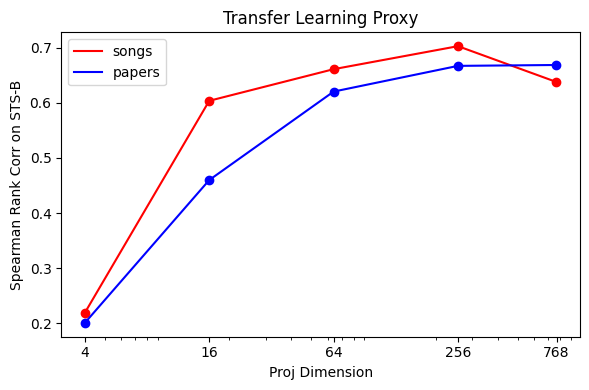

In [ ]:
# ---------- 1) proj_size vs sts_cos ----------
plt.figure(figsize=(6, 4))
plt.plot(songs["proj_size"], songs["sts_cos"], color="red", label="songs")
plt.plot(papers["proj_size"], papers["sts_cos"], color="blue", label="papers")
plt.scatter(papers["proj_size"], papers["sts_cos"], color="blue")
plt.scatter(songs["proj_size"], songs["sts_cos"], color="red")
plt.xlabel("Proj Dimension")
plt.ylabel("Spearman Rank Corr on STS-B")
plt.xscale("log")
ticks = [4, 16, 64, 256, 768]
plt.xticks(ticks, [str(t) for t in ticks])
plt.title("Transfer Learning Proxy")
plt.legend()
plt.tight_layout()

save_path = '/content/drive/MyDrive/weights-UML-train/baseline_results/projsize_vs_sts.png'
plt.savefig(save_path, dpi=400, bbox_inches='tight')

plt.show()

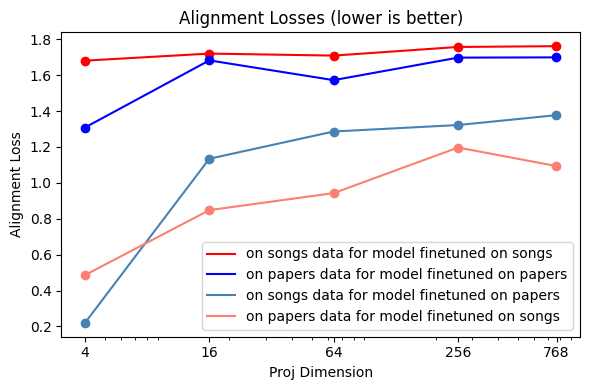

In [ ]:
# ---------- 2) proj_size vs align losses ----------
plt.figure(figsize=(6, 4))


plt.plot(
    songs["proj_size"], songs["align_loss_songs_test"],
    color="red", label="on songs data for model finetuned on songs"
)
plt.scatter(
    songs["proj_size"], songs["align_loss_songs_test"],
    color="red"
)


plt.scatter(
    papers["proj_size"], papers["align_loss_papers_test"],
    color="blue"
)
plt.plot(
    papers["proj_size"], papers["align_loss_papers_test"],
    color="blue", label="on papers data for model finetuned on papers"
)


plt.scatter(
    papers["proj_size"], papers["align_loss_songs_test"],
    color="steelblue"
)
plt.plot(
    papers["proj_size"], papers["align_loss_songs_test"],
    color="steelblue", label="on songs data for model finetuned on papers"
)


plt.scatter(
    songs["proj_size"], songs["align_loss_papers_test"],
    color="salmon"
)
plt.plot(
    songs["proj_size"], songs["align_loss_papers_test"],
    color="salmon", label="on papers data for model finetuned on songs"
)


plt.xlabel("Proj Dimension")
plt.ylabel("Alignment Loss")
plt.xscale("log")
ticks = [4, 16, 64, 256, 768]
plt.xticks(ticks, [str(t) for t in ticks])
plt.title("Alignment Losses (lower is better)")
plt.legend()
plt.tight_layout()


save_path = '/content/drive/MyDrive/weights-UML-train/baseline_results/projsize_vs_alignloss.png'
plt.savefig(save_path, dpi=400, bbox_inches='tight')

plt.show()

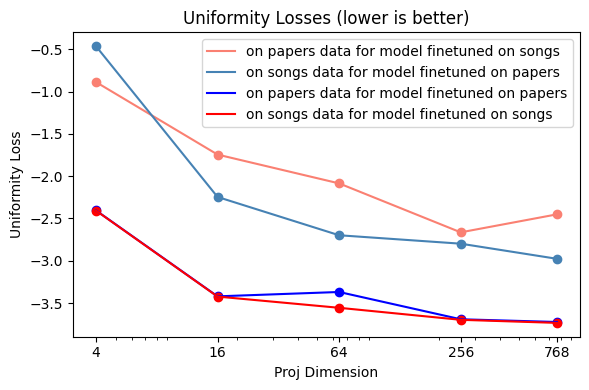

In [ ]:
# ---------- 3) proj_size vs uniform losses ----------
plt.figure(figsize=(6, 4))

plt.scatter(
    songs["proj_size"], songs["uniform_loss_papers_test"],
    color="salmon"
)
plt.plot(
    songs["proj_size"], songs["uniform_loss_papers_test"],
    color="salmon", label="on papers data for model finetuned on songs"
)

plt.scatter(
    papers["proj_size"], papers["uniform_loss_songs_test"],
    color="steelblue"
)
plt.plot(
    papers["proj_size"], papers["uniform_loss_songs_test"],
    color="steelblue", label="on songs data for model finetuned on papers"
)

plt.scatter(
    papers["proj_size"], papers["uniform_loss_papers_test"],
    color="blue"
)
plt.plot(
    papers["proj_size"], papers["uniform_loss_papers_test"],
    color="blue", label="on papers data for model finetuned on papers"
)

plt.plot(
    songs["proj_size"], songs["uniform_loss_songs_test"],
    color="red", label="on songs data for model finetuned on songs"
)
plt.scatter(
    songs["proj_size"], songs["uniform_loss_songs_test"],
    color="red"
)


plt.xlabel("Proj Dimension")
plt.ylabel("Uniformity Loss")
plt.xscale("log")
ticks = [4, 16, 64, 256, 768]
plt.xticks(ticks, [str(t) for t in ticks])
plt.title("Uniformity Losses (lower is better)")
plt.legend()
plt.tight_layout()


save_path = '/content/drive/MyDrive/weights-UML-train/baseline_results/projsize_vs_uniformloss.png'
plt.savefig(save_path, dpi=400, bbox_inches='tight')

plt.show()

In [ ]:
def boxplot_like_logwidth(
    ax, df, proj_col,
    median_col, std_col, min_col, max_col,
    color="red", label=None,
    half_width_log=0.05,  # width in log10 units (on each side)
):
    """
    Pseudo-boxplots with constant *visual* width on a log-scaled x-axis.

    - x positions are in data space (proj_size)
    - widths are defined in log10 space, then converted back:
        left  = 10**(log10(x) - half_width_log)
        right = 10**(log10(x) + half_width_log)
    """
    if df.empty:
        return

    for _, row in df.iterrows():
        x = row[proj_col]
        med = row[median_col]
        std = row[std_col]
        y_min = row[min_col]
        y_max = row[max_col]

        x_log = np.log10(x)
        left = 10 ** (x_log - half_width_log)
        right = 10 ** (x_log + half_width_log)

        # whisker
        ax.vlines(x, y_min, y_max, color=color, alpha=0.7)

        # box (median ± std)
        ax.add_patch(
            Rectangle(
                (left, med - std),
                right - left,
                2 * std,
                edgecolor=color,
                facecolor=color,
                alpha=0.2,
            )
        )

        # median line
        ax.hlines(med, left, right, color=color, linewidth=2)

    if label is not None:
        ax.scatter([], [], color=color, alpha=0.7, label=label)  # dummy for legend

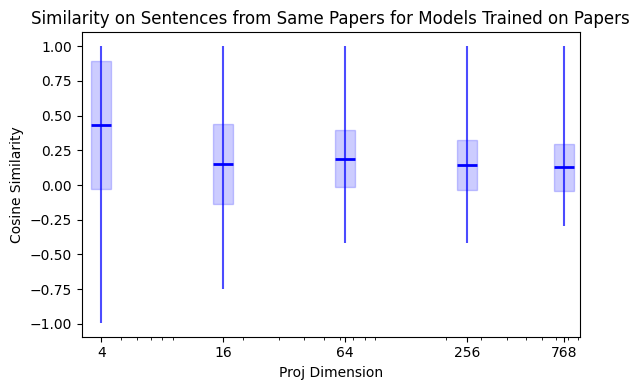

In [ ]:
plt.figure(figsize=(6, 4))
ax = plt.gca()

ax.set_xscale("log")

boxplot_like_logwidth(
    ax, papers, "proj_size",
    "samedoc_papers_test_median",
    "samedoc_papers_test_std",
    "samedoc_papers_test_min",
    "samedoc_papers_test_max",
    color="blue",
    label="papers",
    half_width_log=0.05,   # tweak if you want wider/narrower boxes
)

plt.xlabel("Proj Dimension")
plt.ylabel("Cosine Similarity")
ticks = [4, 16, 64, 256, 768]
plt.xticks(ticks, [str(t) for t in ticks])
plt.title("Similarity on Sentences from Same Papers for Models Trained on Papers")
xmin = min(ticks)
xmax = max(ticks)
plt.xlim(xmin * 0.8, xmax * 1.2)
plt.tight_layout()

save_path = '/content/drive/MyDrive/weights-UML-train/baseline_results/projsize_vs_similarities_papersdata_papersmodel.png'
plt.savefig(save_path, dpi=400, bbox_inches='tight')

plt.show()


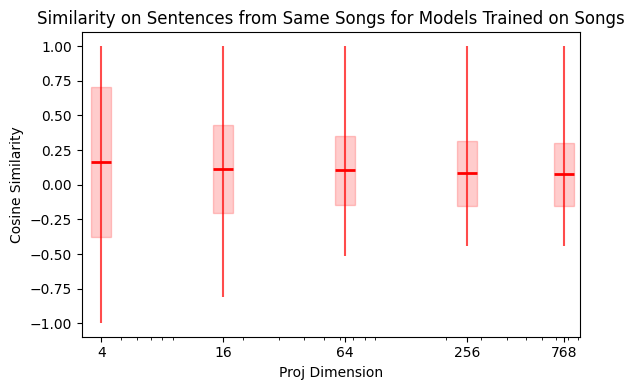

In [ ]:
plt.figure(figsize=(6, 4))
ax = plt.gca()

ax.set_xscale("log")

boxplot_like_logwidth(
    ax, songs, "proj_size",
    "samedoc_songs_test_median",
    "samedoc_songs_test_std",
    "samedoc_songs_test_min",
    "samedoc_songs_test_max",
    color="red",
    half_width_log=0.05,   # tweak if you want wider/narrower boxes
)

plt.xlabel("Proj Dimension")
plt.ylabel("Cosine Similarity")
ticks = [4, 16, 64, 256, 768]
plt.xticks(ticks, [str(t) for t in ticks])
plt.title("Similarity on Sentences from Same Songs for Models Trained on Songs")
xmin = min(ticks)
xmax = max(ticks)
plt.xlim(xmin * 0.8, xmax * 1.2)
plt.tight_layout()

save_path = '/content/drive/MyDrive/weights-UML-train/baseline_results/projsize_vs_similarities_songsdata_songsmodel.png'
plt.savefig(save_path, dpi=400, bbox_inches='tight')

plt.show()


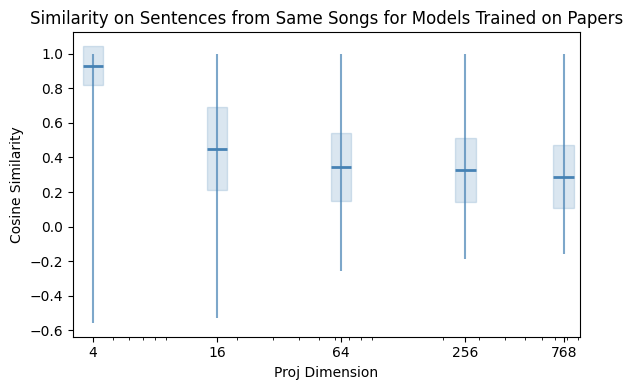

In [ ]:
plt.figure(figsize=(6, 4))
ax = plt.gca()

ax.set_xscale("log")

boxplot_like_logwidth(
    ax, papers, "proj_size",
    "samedoc_songs_test_median",
    "samedoc_songs_test_std",
    "samedoc_songs_test_min",
    "samedoc_songs_test_max",
    color="steelblue",
    half_width_log=0.05,   # tweak if you want wider/narrower boxes
)

plt.xlabel("Proj Dimension")
plt.ylabel("Cosine Similarity")
ticks = [4, 16, 64, 256, 768]
plt.xticks(ticks, [str(t) for t in ticks])
plt.title("Similarity on Sentences from Same Songs for Models Trained on Papers")
xmin = min(ticks)
xmax = max(ticks)
plt.xlim(xmin * 0.8, xmax * 1.2)
plt.tight_layout()

save_path = '/content/drive/MyDrive/weights-UML-train/baseline_results/projsize_vs_similarities_songsdata_papersmodel.png'
plt.savefig(save_path, dpi=400, bbox_inches='tight')

plt.show()

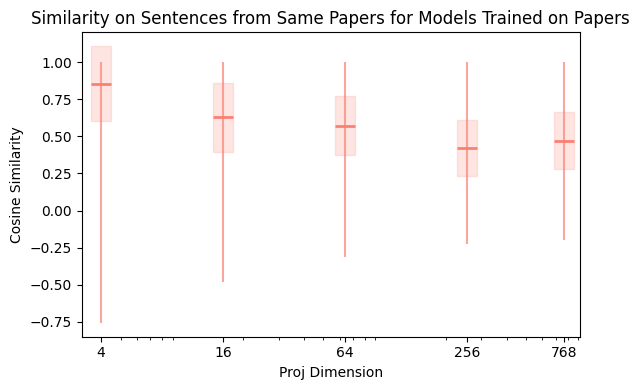

In [ ]:
plt.figure(figsize=(6, 4))
ax = plt.gca()

ax.set_xscale("log")

boxplot_like_logwidth(
    ax, songs, "proj_size",
    "samedoc_papers_test_median",
    "samedoc_papers_test_std",
    "samedoc_papers_test_min",
    "samedoc_papers_test_max",
    color="salmon",
    half_width_log=0.05,   # tweak if you want wider/narrower boxes
)

plt.xlabel("Proj Dimension")
plt.ylabel("Cosine Similarity")
ticks = [4, 16, 64, 256, 768]
plt.xticks(ticks, [str(t) for t in ticks])
plt.title("Similarity on Sentences from Same Papers for Models Trained on Papers")
xmin = min(ticks)
xmax = max(ticks)
plt.xlim(xmin * 0.8, xmax * 1.2)
plt.tight_layout()

save_path = '/content/drive/MyDrive/weights-UML-train/baseline_results/projsize_vs_similarities_papersdata_songsmodel.png'
plt.savefig(save_path, dpi=400, bbox_inches='tight')

plt.show()
